In [37]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.impute import SimpleImputer

In [20]:
train_df = pd.read_csv('./data/raw/train.csv')
test_df = pd.read_csv('./data/raw/test.csv')
samp_submission = pd.read_csv('./data/raw/gender_submission.csv')

#### Preprocessing/Cleaning/EDA

In [77]:
train = train_df.drop(columns=['Ticket', 'Cabin', 'Name'])
test = test_df.drop(columns=['Ticket', 'Cabin', 'Name'])

In [78]:
train['Fare'] = np.round(train['Fare'],2)
test['Fare'] = np.round(test['Fare'],2)

In [53]:
train.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,0,3,male,22.0,1,0,7.25,S
1,2,1,1,female,38.0,1,0,71.28,C
2,3,1,3,female,26.0,0,0,7.92,S
3,4,1,1,female,35.0,1,0,53.10,S
4,5,0,3,male,35.0,0,0,8.05,S


In [54]:
test.head()

,PassengerId,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,892,3,male,34.5,0,0,7.83,Q
1,893,3,female,47.0,1,0,7.00,S
2,894,2,male,62.0,0,0,9.69,Q
3,895,3,male,27.0,0,0,8.66,S
4,896,3,female,22.0,1,1,12.29,S


In [55]:
samp_submission.head()

,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1


In [56]:
train.shape

(891, 9)

In [57]:
# Missing Values

In [79]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Sex          891 non-null    object 
 4   Age          714 non-null    float64
 5   SibSp        891 non-null    int64  
 6   Parch        891 non-null    int64  
 7   Fare         891 non-null    float64
 8   Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(2)
memory usage: 62.8+ KB


In [80]:
imputer = SimpleImputer(strategy='most_frequent')
train.iloc[:,:] = imputer.fit_transform(train)
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Sex          891 non-null    object 
 4   Age          891 non-null    float64
 5   SibSp        891 non-null    int64  
 6   Parch        891 non-null    int64  
 7   Fare         891 non-null    float64
 8   Embarked     891 non-null    object 
dtypes: float64(2), int64(5), object(2)
memory usage: 62.8+ KB


In [82]:
train.nunique()

PassengerId    891
Survived         2
Pclass           3
Sex              2
Age             88
SibSp            7
Parch            7
Fare           236
Embarked         3
dtype: int64

<Axes: >

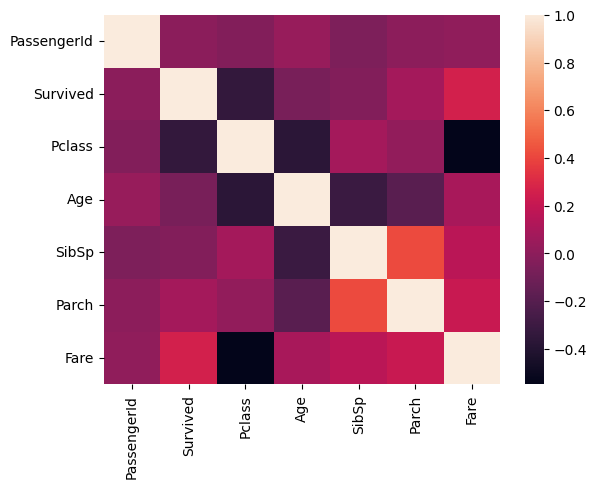

In [9]:
corr = train.corr(numeric_only=True)
sns.heatmap(corr)

In [84]:
# Univariate Analysis

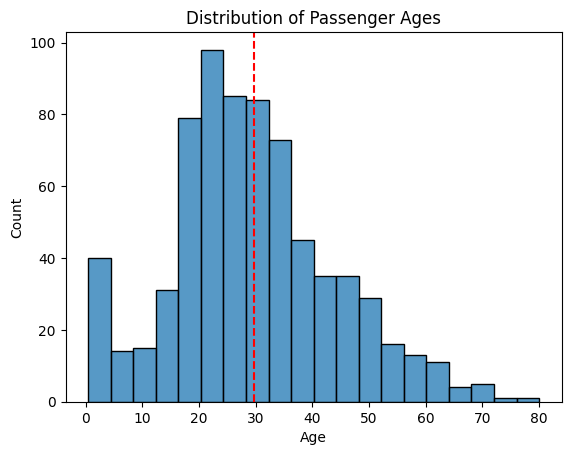

In [10]:
sns.histplot(train['Age'])
plt.title('Distribution of Passenger Ages')
plt.axvline(train['Age'].mean(), color='r', linestyle='--')
plt.show()

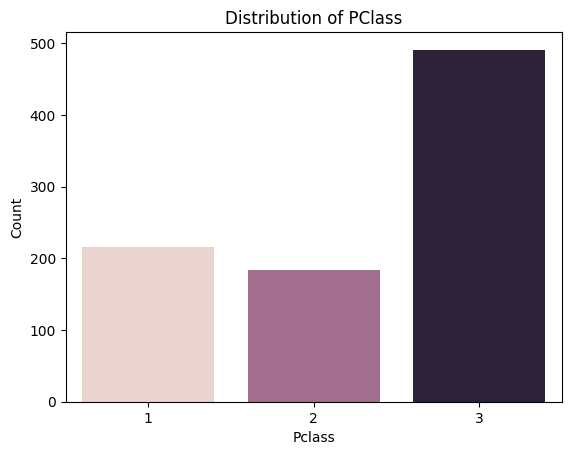

In [106]:
pclass_count = train.groupby('Pclass').size().reset_index(name='Pclass_count')
ax = sns.barplot(pclass_count, x='Pclass', y='Pclass_count', hue='Pclass', legend=False)
ax.set_ylabel('Count')
plt.title('Distribution of PClass')
plt.show()

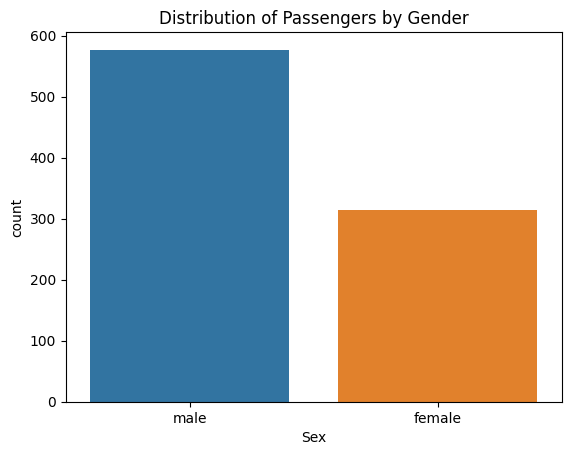

In [110]:
sns.countplot(train, x='Sex', hue='Sex')
plt.title('Distribution of Passengers by Gender')
plt.show()

In [111]:
# Multivariate Analysis

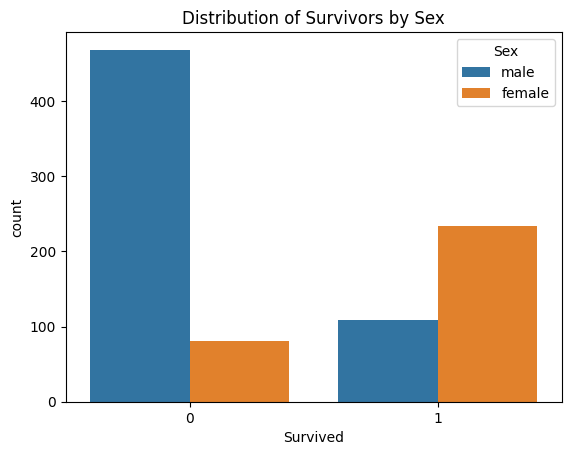

In [11]:
sns.countplot(train, x='Survived', hue='Sex')
plt.title('Distribution of Survivors by Sex')
plt.show()

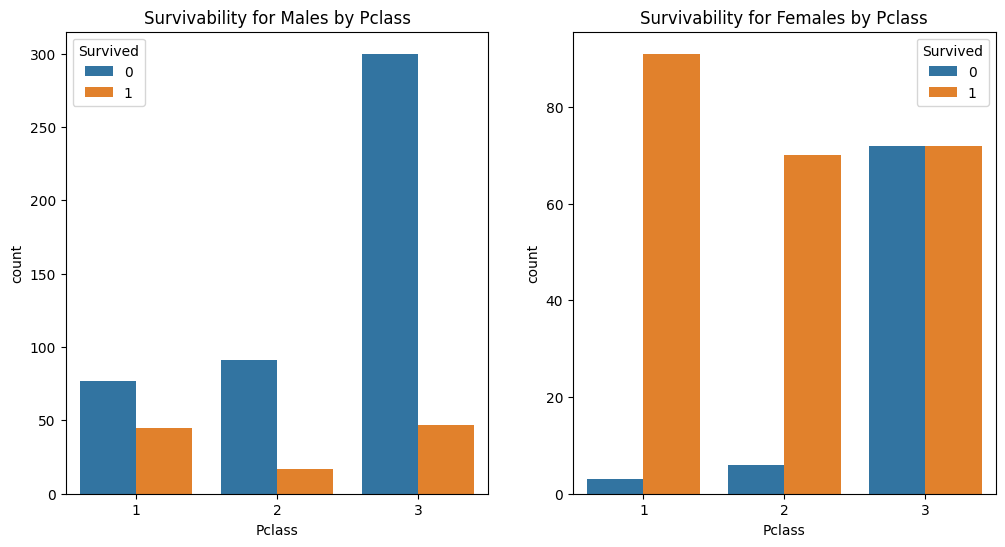

In [116]:
# Distribution of Survivors by Pclass & Gender
male_df = train.query('Sex == "male"')
female_df = train.query('Sex == "female"')
fig, (ax1, ax2) = plt.subplots(figsize=(12,6), ncols=2)
sns.countplot(male_df, x='Pclass', hue='Survived', ax=ax1)
sns.countplot(female_df, x='Pclass', hue='Survived', ax=ax2)
ax1.set_title('Survivability for Males by Pclass')
ax2.set_title('Survivability for Females by Pclass')
plt.show()

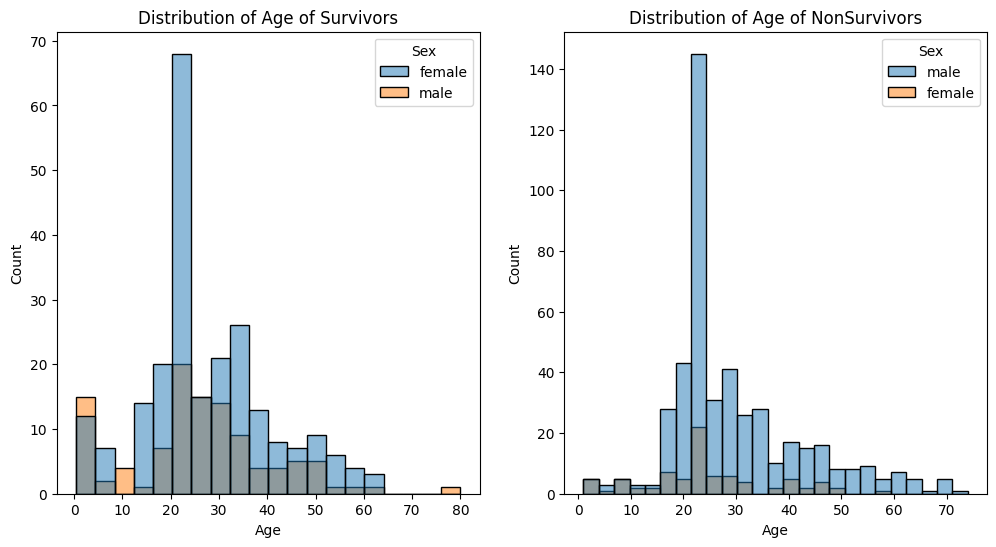

In [83]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 6))
survived = train.query('Survived == 1')
died = train.query('Survived==0')
sns.histplot(survived, x='Age', ax=ax1, hue='Sex')
sns.histplot(died, x='Age',  ax=ax2, hue='Sex')
ax1.set_title('Distribution of Age of Survivors')
ax2.set_title('Distribution of Age of NonSurvivors')
plt.show()

In [13]:
features = train.drop(columns='Survived', axis=1)
target = train['Survived']

In [14]:
features.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
